In [1]:
import sys, os
sys.path.append("../../")  # if needed
import pandas as pd
import data_loading as dl
import numpy as np
import matplotlib.pyplot as plt
from cc0pi_cached import _apply_cc0pi_cached, _df_fp, _hash_file, _code_fp, generate_hash, load_runs_with_cc0pi_bdt


In [2]:
#Load the OG run (no BDT yet)
rundata, weights, data_pot = dl.load_runs(
    ["1"],
    enable_cache=True,
    data="bnb",
    loadshowervariables=False,
    loadnumuvariables=True,
    load_numu_tki=False,
    loadpi0variables=False,
    loadrecoveryvars=False,
    loadsystematics=True,
    blinded=True,
    use_bdt=False,
)


Loading run 1


In [42]:
mc_full = rundata["mc"]

In [43]:
# Take a small subset
mc_small = mc_full.head(10000).copy()

In [116]:
from numu_tki.cc0pi_analyzer import apply_ccnp0pi_stv

model_path = "/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json"

mc_small_bdt = apply_ccnp0pi_stv(mc_small.copy(), model_path=model_path)

print("is_mc counts:\n", mc_small_bdt["is_mc"].value_counts())
print("mc_is_signal sum:", mc_small_bdt["mc_is_signal"].sum())
print("mc_muon_in_mom_range sum:", mc_small_bdt["mc_muon_in_mom_range"].sum())
print("mc_lead_p_in_mom_range sum:", mc_small_bdt["mc_lead_p_in_mom_range"].sum())


is_mc counts:
 True    10000
Name: is_mc, dtype: int64
mc_is_signal sum: 998
mc_muon_in_mom_range sum: 1860
mc_lead_p_in_mom_range sum: 1443


In [117]:
import numpy as np
import pandas as pd

def _b(x):  # safe bool
    return x.fillna(False).astype(bool)

def compute_eff_pur_df(df: pd.DataFrame) -> pd.DataFrame:
    # selection
    stages = [
        ("no cuts",                                       lambda d: d["is_mc"]==d["is_mc"]),  # always True
        ("in FV",                                         lambda d: _b(d["sel_reco_vertex_in_FV"])),
        ("starts contained",                              lambda d: _b(d["sel_reco_vertex_in_FV"]) & _b(d["sel_pfp_starts_in_PCV"])),
        ("CCincl",                                        lambda d: _b(d["sel_nu_mu_cc"])),
        ("#mu momentum limits",                           lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("no showers",                                    lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"])),
        ("#mu contained",                                 lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"])),
        ("#mu quality",                                   lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"])),
        ("has p candidate",                               lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"])),
        ("p contained",                                   lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"])),
        ("proton PID",                                    lambda d: _b(d["sel_nu_mu_cc"]) & _b(d["sel_no_reco_showers"]) & _b(d["sel_muon_passed_mom_cuts"]) & _b(d["sel_muon_contained"]) & _b(d["sel_muon_quality_ok"]) & _b(d["sel_has_p_candidate"]) & _b(d["sel_protons_contained"]) & _b(d["sel_passed_proton_pid_cut"])),
        ("p momentum limits (== sel_CCNp0pi)",            lambda d: _b(d["sel_CCNp0pi"])),
        ("p momentum limits (== sel_CC1p0pi)",            lambda d: _b(d["sel_CC1p0pi"])),
    ]

    mc  = _b(mc_small_bdt["is_mc"])
    sig = _b(mc_small_bdt["mc_is_signal"]) & mc  # C++ uses signal = "mc_is_signal && is_mc"

    rows = []
    for idx, (name, sel_fun) in enumerate(stages, start=1):
        sel = sel_fun(df) & mc                      # selection && is_mc
        num_signal           = int(sig.sum())       # denominator for efficiency
        num_selected         = int(sel.sum())       # denominator for purity
        num_selected_signal  = int((sig & sel).sum())

        eff = (num_selected_signal / num_signal)   if num_signal   else np.nan
        pur = (num_selected_signal / num_selected) if num_selected else np.nan

        rows.append(dict(
            step=idx, stage=name,
            num_signal=num_signal,
            num_selected=num_selected,
            num_selected_signal=num_selected_signal,
            efficiency=eff, purity=pur,
        ))

    return pd.DataFrame(rows)

# Example:
results = compute_eff_pur_df(mc_small_bdt)  # df contains your selection booleans from apply_ccnp0pi_stv(...)
print(results)


    step                               stage  num_signal  num_selected  \
0      1                             no cuts         998         10000   
1      2                               in FV         998          2202   
2      3                    starts contained         998          2004   
3      4                              CCincl         998           924   
4      5                 #mu momentum limits         998           883   
5      6                          no showers         998           883   
6      7                       #mu contained         998           361   
7      8                         #mu quality         998           291   
8      9                     has p candidate         998           168   
9     10                         p contained         998           168   
10    11                          proton PID         998           168   
11    12  p momentum limits (== sel_CCNp0pi)         998           168   
12    13  p momentum limits (== sel_CC

In [118]:
mc_small_bdt = mc_small_bdt.loc[:, ~mc_small_bdt.columns.duplicated(keep="last")]


In [119]:
from collections import Counter
print([c for c, n in Counter(mc_small_bdt.columns).items() if n > 1])

category_map = {
    0:  "Unknown",
    1:  "SignalCCQE",
    2:  "SignalCCMEC",
    3:  "SignalCCRES",
    4:  "SignalOther",
    5:  "NuMuCCNpi",
    6:  "NuMuCC0pi0p",   # unused but reserved
    7:  "NuMuCCOther",
    8:  "NuECC",
    9:  "NC",
    10: "OOFV",
    11: "Other",
}

mc_small_bdt["category_name"] = (
    mc_small_bdt["category"]
    .astype("Int64", errors="ignore")  
    .map(category_map)
    .fillna("Unknown")
)


[]


In [120]:
print(mc_small_bdt[["category", "category_name"]].head())
print(mc_small_bdt["category_name"].value_counts())


   category category_name
0         9            NC
1        10          OOFV
2        10          OOFV
3         1    SignalCCQE
4         5     NuMuCCNpi
OOFV           7277
SignalCCQE      911
NC              776
NuMuCCNpi       579
SignalCCMEC     209
SignalCCRES     183
NuMuCCOther      46
SignalOther      11
Other             8
Name: category_name, dtype: int64


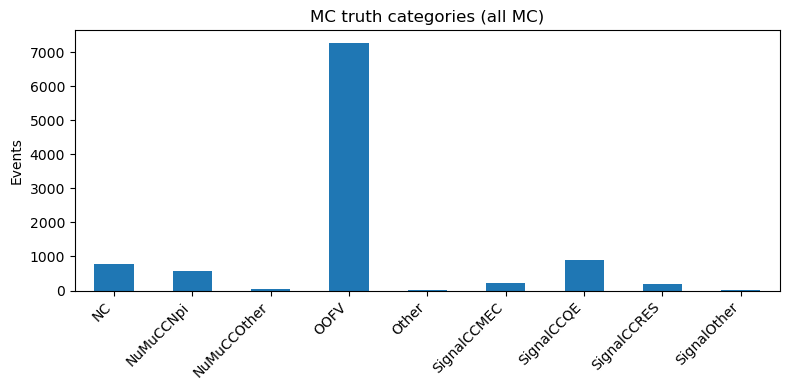

In [121]:
counts = mc_small_bdt.loc[mc_small_bdt["is_mc"], "category_name"].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
counts.plot(kind="bar")
plt.ylabel("Events")
plt.title("MC truth categories (all MC)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


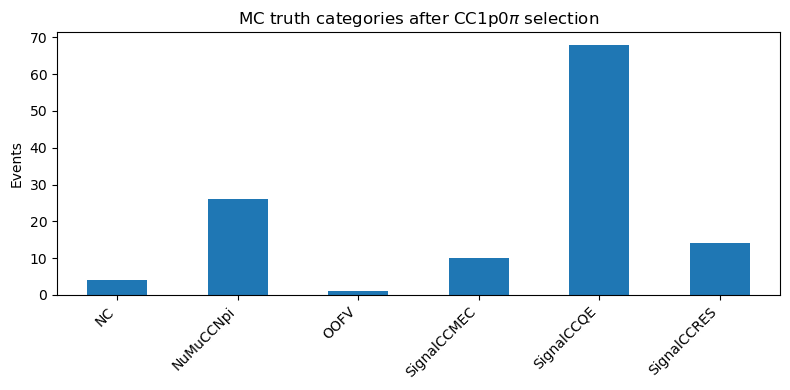

In [122]:
sel = mc_small_bdt["sel_CC1p0pi"].fillna(False).astype(bool) & mc_small_bdt["is_mc"].fillna(False)
counts_sel = mc_small_bdt.loc[sel, "category_name"].value_counts().sort_index()

plt.figure(figsize=(8,4))
counts_sel.plot(kind="bar")
plt.ylabel("Events")
plt.title("MC truth categories after CC1p0$\pi$ selection")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Total MC: 10000
Selected CC1p0pi: 123

Truth categories BEFORE cuts:
OOFV           7277
SignalCCQE      911
NC              776
NuMuCCNpi       579
SignalCCMEC     209
SignalCCRES     183
NuMuCCOther      46
SignalOther      11
Other             8
Name: category_name, dtype: int64

Truth categories AFTER CC1p0pi selection:
SignalCCQE     68
NuMuCCNpi      26
SignalCCRES    14
SignalCCMEC    10
NC              4
OOFV            1
Name: category_name, dtype: int64


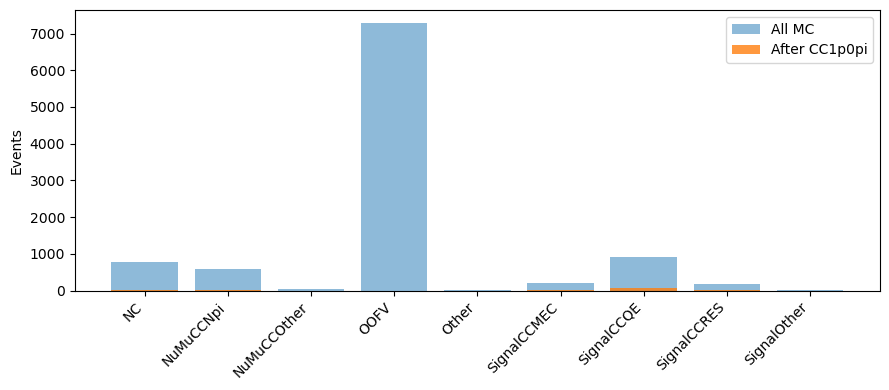

In [123]:
# only MC events
mc_mask = mc_small_bdt["is_mc"].fillna(False).astype(bool)

# final signal-like reco selection (CC1p0pi)
sel = mc_mask & mc_small_bdt["sel_CC1p0pi"].fillna(False).astype(bool)

print("Total MC:", mc_mask.sum())
print("Selected CC1p0pi:", sel.sum())
print()

print("Truth categories BEFORE cuts:")
print(mc_small_bdt.loc[mc_mask, "category_name"].value_counts())

print("\nTruth categories AFTER CC1p0pi selection:")
print(mc_small_bdt.loc[sel, "category_name"].value_counts())


before = mc_small_bdt.loc[mc_mask, "category_name"].value_counts().sort_index()
after  = mc_small_bdt.loc[sel,     "category_name"].value_counts().reindex(before.index, fill_value=0)

plt.figure(figsize=(9,4))
plt.bar(before.index, before.values, alpha=0.5, label="All MC")
plt.bar(after.index,  after.values,  alpha=0.8, label="After CC1p0pi")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Events")
plt.legend()
plt.tight_layout()
plt.show()



### C++ LOGIC 

In [124]:
mc = mc_small_bdt

def _b(x):  # safe bool
    return x.fillna(False).astype(bool)

def compute_eff_pur_cpp_style(df: pd.DataFrame, signal_mask, selection_mask):

    is_mc = _b(mc["is_mc"])

    sig = _b(signal_mask) & is_mc               # signal && is_mc
    sel = _b(selection_mask) & is_mc            # selection && is_mc

    num_signal = sig.sum()
    num_selected = sel.sum()
    num_selected_signal = (sig & sel).sum()

    eff = num_selected_signal / num_signal if num_signal else np.nan
    pur = num_selected_signal / num_selected if num_selected else np.nan
    return num_signal, num_selected, num_selected_signal, eff, pur


sig_mask = _b(mc["mc_is_signal"])

stages = [
    ("no cuts",                                       mc["is_mc"] == mc["is_mc"]),
    ("in FV",                                         mc["sel_reco_vertex_in_FV"]),
    ("starts contained",                              mc["sel_reco_vertex_in_FV"] & mc["sel_pfp_starts_in_PCV"]),
    ("CCincl",                                        mc["sel_nu_mu_cc"]),
    ("#mu momentum limits",                           mc["sel_nu_mu_cc"] & mc["sel_muon_passed_mom_cuts"]),
    ("no showers",                                    mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"]),
    ("#mu contained",                                 mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"] & mc["sel_muon_contained"]),
    ("#mu quality",                                   mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"] & mc["sel_muon_contained"] & mc["sel_muon_quality_ok"]),
    ("has p candidate",                               mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"] & mc["sel_muon_contained"] & mc["sel_muon_quality_ok"] & mc["sel_has_p_candidate"]),
    ("p contained",                                   mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"] & mc["sel_muon_contained"] & mc["sel_muon_quality_ok"] & mc["sel_has_p_candidate"] & mc["sel_protons_contained"]),
    ("proton PID",                                    mc["sel_nu_mu_cc"] & mc["sel_no_reco_showers"] & mc["sel_muon_passed_mom_cuts"] & mc["sel_muon_contained"] & mc["sel_muon_quality_ok"] & mc["sel_has_p_candidate"] & mc["sel_protons_contained"] & mc["sel_passed_proton_pid_cut"]),
    ("p momentum limits (== sel_CCNp0pi)",            mc["sel_CCNp0pi"]),
    ("p momentum limits (== sel_CC1p0pi)",            mc["sel_CC1p0pi"]),
]

rows = []
for i, (name, sel_mask) in enumerate(stages, start=1):
    nsig, nsel, nsel_sig, eff, pur = compute_eff_pur_cpp_style(mc, sig_mask, sel_mask)
    rows.append(dict(
        step=i,
        stage=name,
        num_signal=nsig,
        num_selected=nsel,
        num_selected_signal=nsel_sig,
        efficiency=eff,
        purity=pur,
    ))

results_cpp_style = pd.DataFrame(rows)
print(results_cpp_style)


    step                               stage  num_signal  num_selected  \
0      1                             no cuts         998         10000   
1      2                               in FV         998          2202   
2      3                    starts contained         998          2004   
3      4                              CCincl         998           924   
4      5                 #mu momentum limits         998           883   
5      6                          no showers         998           883   
6      7                       #mu contained         998           361   
7      8                         #mu quality         998           291   
8      9                     has p candidate         998           168   
9     10                         p contained         998           168   
10    11                          proton PID         998           168   
11    12  p momentum limits (== sel_CCNp0pi)         998           168   
12    13  p momentum limits (== sel_CC

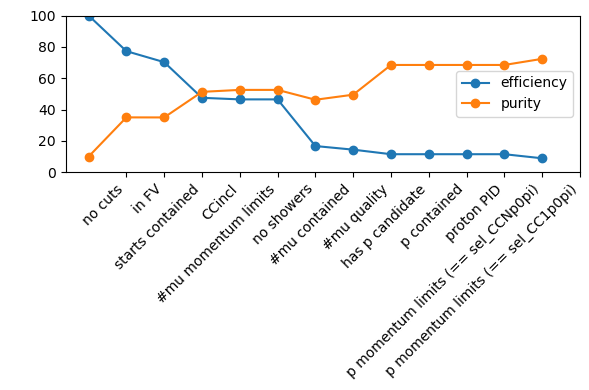

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(100*results_cpp_style["efficiency"], marker="o", label="efficiency")
plt.plot(100*results_cpp_style["purity"], marker="o", label="purity")
plt.ylim(0, 100.0)
plt.xticks(results_cpp_style["step"], results_cpp_style["stage"], rotation=45, ha="right")
plt.ylabel(" ")
plt.tight_layout()
plt.legend()
plt.show()


In [126]:
for i, (name, sel_mask) in enumerate(stages, start=1):
    sel = _b(sel_mask) & _b(mc["is_mc"])
    print(f"\nStage {i}: {name}")
    print(mc.loc[sel, "category_name"].value_counts())



Stage 1: no cuts
OOFV           7277
SignalCCQE      911
NC              776
NuMuCCNpi       579
SignalCCMEC     209
SignalCCRES     183
NuMuCCOther      46
SignalOther      11
Other             8
Name: category_name, dtype: int64

Stage 2: in FV
SignalCCQE     693
NuMuCCNpi      466
OOFV           379
NC             302
SignalCCMEC    162
SignalCCRES    155
NuMuCCOther     32
SignalOther      9
Other            4
Name: category_name, dtype: int64

Stage 3: starts contained
SignalCCQE     650
NuMuCCNpi      409
OOFV           350
NC             282
SignalCCMEC    144
SignalCCRES    132
NuMuCCOther     25
SignalOther      8
Other            4
Name: category_name, dtype: int64

Stage 4: CCincl
SignalCCQE     451
NuMuCCNpi      165
SignalCCMEC     95
SignalCCRES     80
OOFV            73
NC              39
NuMuCCOther     15
SignalOther      4
Other            2
Name: category_name, dtype: int64

Stage 5: #mu momentum limits
SignalCCQE     444
NuMuCCNpi      161
SignalCCMEC     91
Signal

In [127]:
sig = _b(mc["mc_is_signal"])
sel = _b(mc["sel_CCNp0pi"])

missed = mc[sig & ~sel]

print("Signal events:", sig.sum())
print("Selected CCNp0pi:", (sig & sel).sum())
print("Missed signal:", len(missed))

for idx, row in missed.head(10).iterrows():
    print("\nEvent index:", idx)
    print("  mc_vertex_in_FV:", row["mc_vertex_in_FV"])
    print("  mc_muon_in_mom_range:", row["mc_muon_in_mom_range"])
    print("  mc_lead_p_in_mom_range:", row["mc_lead_p_in_mom_range"])
    print("  sel_nu_mu_cc:", row["sel_nu_mu_cc"])
    print("  sel_muon_passed_mom_cuts:", row["sel_muon_passed_mom_cuts"])
    print("  sel_muon_contained:", row["sel_muon_contained"])
    print("  sel_muon_quality_ok:", row["sel_muon_quality_ok"])
    print("  sel_has_p_candidate:", row["sel_has_p_candidate"])
    print("  sel_protons_contained:", row["sel_protons_contained"])
    print("  sel_lead_p_passed_mom_cuts:", row["sel_lead_p_passed_mom_cuts"])


Signal events: 998
Selected CCNp0pi: 115
Missed signal: 883

Event index: 3
  mc_vertex_in_FV: True
  mc_muon_in_mom_range: True
  mc_lead_p_in_mom_range: True
  sel_nu_mu_cc: True
  sel_muon_passed_mom_cuts: True
  sel_muon_contained: True
  sel_muon_quality_ok: True
  sel_has_p_candidate: False
  sel_protons_contained: False
  sel_lead_p_passed_mom_cuts: False

Event index: 17
  mc_vertex_in_FV: True
  mc_muon_in_mom_range: True
  mc_lead_p_in_mom_range: True
  sel_nu_mu_cc: True
  sel_muon_passed_mom_cuts: True
  sel_muon_contained: False
  sel_muon_quality_ok: True
  sel_has_p_candidate: True
  sel_protons_contained: True
  sel_lead_p_passed_mom_cuts: True

Event index: 22
  mc_vertex_in_FV: True
  mc_muon_in_mom_range: True
  mc_lead_p_in_mom_range: True
  sel_nu_mu_cc: True
  sel_muon_passed_mom_cuts: True
  sel_muon_contained: False
  sel_muon_quality_ok: True
  sel_has_p_candidate: True
  sel_protons_contained: True
  sel_lead_p_passed_mom_cuts: True

Event index: 41
  mc_verte

In [128]:
sig = _b(mc["mc_is_signal"])

c_nu_mu_cc   = _b(mc["sel_nu_mu_cc"])
c_no_showers = _b(mc["sel_no_reco_showers"])
c_mu_mom     = _b(mc["sel_muon_passed_mom_cuts"])
c_mu_cont    = _b(mc["sel_muon_contained"])
c_mu_qual    = _b(mc["sel_muon_quality_ok"])
c_has_p      = _b(mc["sel_has_p_candidate"])
c_p_cont     = _b(mc["sel_protons_contained"])
c_lead_p_mom = _b(mc["sel_lead_p_passed_mom_cuts"])

print("Total signal:", sig.sum())

# Failures at each stage in the CCNp0π chain:
fail_nu_mu_cc   = sig & ~c_nu_mu_cc
fail_no_showers = sig & c_nu_mu_cc & ~c_no_showers
fail_mu_mom     = sig & c_nu_mu_cc & c_no_showers & ~c_mu_mom
fail_mu_cont    = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & ~c_mu_cont
fail_mu_qual    = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & c_mu_cont & ~c_mu_qual
fail_has_p      = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & c_mu_cont & c_mu_qual & ~c_has_p
fail_p_cont     = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & c_mu_cont & c_mu_qual & c_has_p & ~c_p_cont
fail_lead_p_mom = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & c_mu_cont & c_mu_qual & c_has_p & c_p_cont & ~c_lead_p_mom
passed_all      = sig & c_nu_mu_cc & c_no_showers & c_mu_mom & c_mu_cont & c_mu_qual & c_has_p & c_p_cont & c_lead_p_mom

print("Fail numuCC:             ", fail_nu_mu_cc.sum())
print("Fail no-showers:       ", fail_no_showers.sum())
print("Fail muon momentum:       ", fail_mu_mom.sum())
print("Fail muon contained:      ", fail_mu_cont.sum())
print("Fail muon quality:        ", fail_mu_qual.sum())
print("Fail has p candidate:  ", fail_has_p.sum())
print("Fail p contained:      ", fail_p_cont.sum())
print("Fail lead-p momentum:  ", fail_lead_p_mom.sum())
print("Pass all CCNp0pi cuts: ", passed_all.sum())  


Total signal: 998
Fail numuCC:              524
Fail no-showers:        0
Fail muon momentum:        10
Fail muon contained:       297
Fail muon quality:         23
Fail has p candidate:   29
Fail p contained:       0
Fail lead-p momentum:   0
Pass all CCNp0pi cuts:  115


In [129]:
print(mc_small_bdt["trk_pid_chimu_v"])

0                                           []
1                                           []
2                                           []
3        [5.311456680297852, 18.0074405670166]
4       [9.479299545288086, 16.29832649230957]
                         ...                  
9995                                        []
9996     [8.957352638244629, 11.9119873046875]
9997                                        []
9998                                        []
9999                      [52.526763916015625]
Name: trk_pid_chimu_v, Length: 10000, dtype: object


#### ECAL